In [1]:
import os
import glob
import pandas as pd

base = os.path.expanduser("~/IDX-Exchange-Internship-Data_Science-Summer2026/california")

files = glob.glob(os.path.join(base, "CRMLSSold*.csv"))

print("Base folder:", base)
print("Folder exists:", os.path.exists(base))
print("Files found:", len(files))
print(files[:5])

Base folder: /Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california
Folder exists: True
Files found: 30
['/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202404_filled.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202409.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202408.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202501_filled.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold20220101_20231231_filled.csv']


In [2]:
# Load all files
dfs = []
for f in sorted(files):
    temp = pd.read_csv(f, low_memory=False)
    temp["_source_file"] = os.path.basename(f)  # track which file each row came from
    print(f"{os.path.basename(f):50s} → {len(temp):>8,} rows, {temp.shape[1]} cols")
    dfs.append(temp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows: {len(df_raw):,}")
print(f"Total columns: {df_raw.shape[1]}")

CRMLSSold20220101_20231231_filled.csv              →  157,828 rows, 81 cols
CRMLSSold202401_filled.csv                         →   17,958 rows, 81 cols
CRMLSSold202402_filled.csv                         →   19,925 rows, 81 cols
CRMLSSold202403_filled.csv                         →   23,276 rows, 81 cols
CRMLSSold202404_filled.csv                         →   24,640 rows, 81 cols
CRMLSSold202405_filled.csv                         →   26,487 rows, 81 cols
CRMLSSold202406_filled.csv                         →   24,328 rows, 81 cols
CRMLSSold202407_filled.csv                         →   26,240 rows, 81 cols
CRMLSSold202408.csv                                →   24,558 rows, 79 cols
CRMLSSold202409.csv                                →   21,267 rows, 79 cols
CRMLSSold202410.csv                                →   23,274 rows, 79 cols
CRMLSSold202411.csv                                →   20,279 rows, 79 cols
CRMLSSold202412.csv                                →   20,241 rows, 79 cols
CRMLSSold202

In [4]:
df_raw["PropertyType"].value_counts()
df_raw["PropertySubType"].value_counts()

PropertySubType
SingleFamilyResidence    484815
Condominium              137769
Townhouse                 45583
Apartment                 17822
Duplex                    14860
ManufacturedOnLand         8058
Triplex                    4560
Quadruplex                 4537
StockCooperative           2681
MixedUse                   2609
Office                     2235
Retail                     1478
Industrial                  931
Cabin                       648
Studio                      570
Business                    533
Warehouse                   380
RoomingHouse                376
SpecialPurpose              215
MultiFamily                 183
BoatSlip                    149
Agriculture                 123
OwnYourOwn                  112
UnimprovedLand              102
Loft                        100
MobileHome                   96
WaterPositionWithLand        93
ManufacturedHome             68
Farm                         30
Timeshare                    29
HotelMotel              

Only keep homes where the property type is Residential and the subtype is SingleFamilyResidence.

In [5]:
df_res = df_raw[
    (df_raw["PropertyType"] == "Residential") &
    (df_raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

In [6]:
eda_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

df_res[eda_cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,3.991550e+05,3.989470e+05,399157.000000,399082.000000,3.923310e+05
mean,1.285092e+06,2.036718e+03,3.476710,2.610133,2.454994e+05
std,5.237207e+06,3.803275e+03,0.960517,1.182700,1.387443e+07
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,6.200000e+05,1.373000e+03,3.000000,2.000000,5.663000e+03
50%,8.890000e+05,1.800000e+03,3.000000,2.000000,7.247000e+03
75%,1.425000e+06,2.417500e+03,4.000000,3.000000,1.034000e+04
max,9.895000e+08,2.308680e+06,45.000000,175.000000,2.087221e+09


In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df_res[eda_cols].isna().sum(),
    "missing_percent": df_res[eda_cols].isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
ClosePrice,2,0.000501
LivingArea,210,0.052611
BedroomsTotal,0,0.000000
BathroomsTotalInteger,75,0.018790
LotSizeSquareFeet,6826,1.710104


In [8]:
df_eda = df_res.copy()

df_eda = df_eda[
    (df_eda["ClosePrice"].notna()) & (df_eda["ClosePrice"] > 0) &
    (df_eda["LivingArea"].notna()) & (df_eda["LivingArea"] > 0) &
    (df_eda["BedroomsTotal"].notna()) & (df_eda["BedroomsTotal"] >= 0) &
    (df_eda["BathroomsTotalInteger"].notna()) & (df_eda["BathroomsTotalInteger"] >= 0) &
    (df_eda["LotSizeSquareFeet"].notna()) & (df_eda["LotSizeSquareFeet"] > 0)
].copy()

print("Rows before basic validity filter:", len(df_res))
print("Rows after basic validity filter:", len(df_eda))
print("Rows removed:", len(df_res) - len(df_eda))

df_eda[
    ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
].describe()

Rows before basic validity filter: 399157
Rows after basic validity filter: 391675
Rows removed: 7482


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,3.916750e+05,3.916750e+05,391675.000000,391675.000000,3.916750e+05
mean,1.279135e+06,2.037730e+03,3.476735,2.606401,2.411262e+05
std,5.263284e+06,3.835940e+03,0.959396,1.147330,1.357762e+07
min,1.150000e+00,2.000000e+00,0.000000,0.000000,1.000000e-02
25%,6.175000e+05,1.374000e+03,3.000000,2.000000,5.663000e+03
50%,8.850000e+05,1.800000e+03,3.000000,2.000000,7.248000e+03
75%,1.423000e+06,2.418000e+03,4.000000,3.000000,1.033400e+04
max,9.895000e+08,2.308680e+06,45.000000,153.000000,2.087221e+09


I created a separate dataframe called df_eda for exploration. Starting from the residential single-family dataset, I kept only rows where the main EDA variables had valid values. I removed rows with missing or zero sale price, missing or zero living area, missing or negative bedrooms or bathrooms, and missing or zero lot size. This makes the histograms and summary statistics more meaningful.

### **1. Plot for ClosePrice**

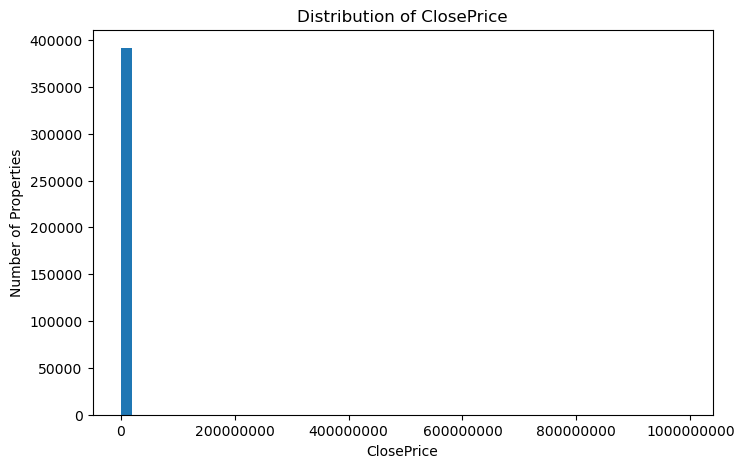

In [10]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 5))
plt.hist(df_eda["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice")
plt.xlabel("ClosePrice")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

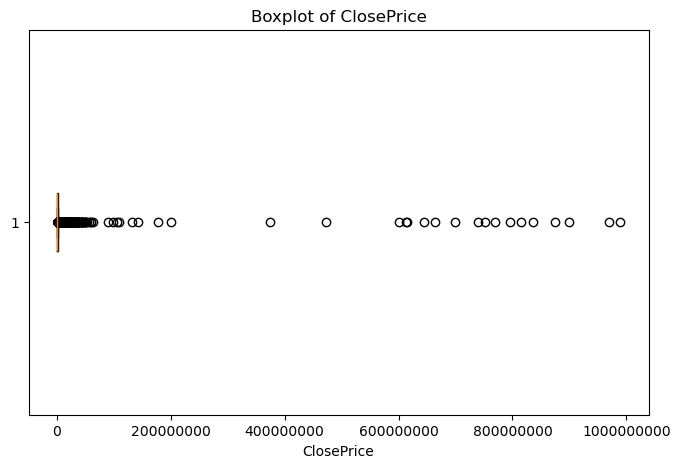

In [11]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_eda["ClosePrice"], vert=False)
plt.title("Boxplot of ClosePrice")
plt.xlabel("ClosePrice")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

The ClosePrice distribution is highly right-skewed. Most residential single-family homes are concentrated at lower price ranges, but a small number of extremely high sale prices stretch the x-axis. Because of these outliers, the full histogram is difficult to interpret, so I created a zoomed-in version using the 99th percentile.

99th percentile ClosePrice: 6150000.0
Rows before zoom filter: 391675
Rows after zoom filter: 387768


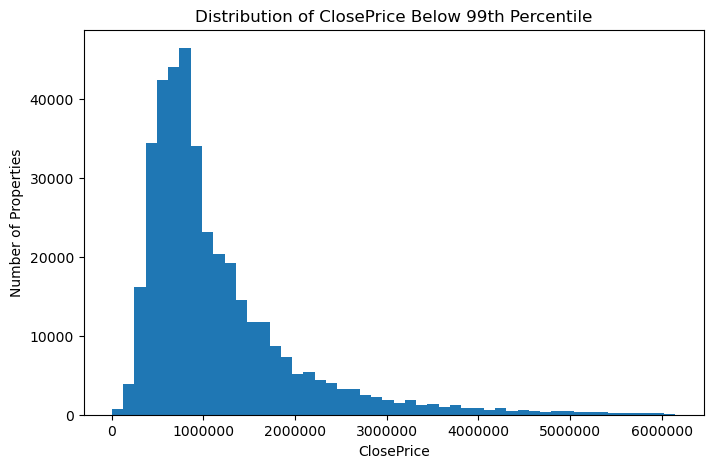

In [12]:
closeprice_99 = df_eda["ClosePrice"].quantile(0.99)

df_close_zoom = df_eda[df_eda["ClosePrice"] <= closeprice_99]

print("99th percentile ClosePrice:", closeprice_99)
print("Rows before zoom filter:", len(df_eda))
print("Rows after zoom filter:", len(df_close_zoom))

plt.figure(figsize=(8, 5))
plt.hist(df_close_zoom["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice Below 99th Percentile")
plt.xlabel("ClosePrice")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

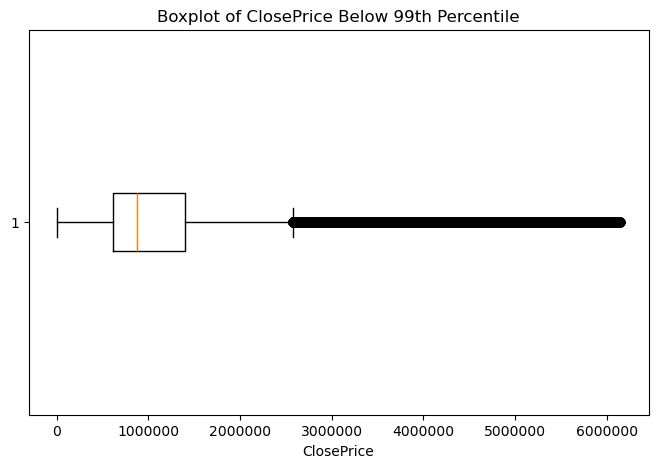

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_close_zoom["ClosePrice"], vert=False)
plt.title("Boxplot of ClosePrice Below 99th Percentile")
plt.xlabel("ClosePrice")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

The first ClosePrice plot was hard to read because a few extremely expensive properties stretched the x-axis. So I made a second version using only values below the 99th percentile. This made the main distribution clearer. From this version, I can see that most single-family residential homes are concentrated around the mid-six-figure to low-seven-figure range, and the distribution is still right-skewed because fewer homes sell at very high prices.

### **2. Plot for LivingArea**

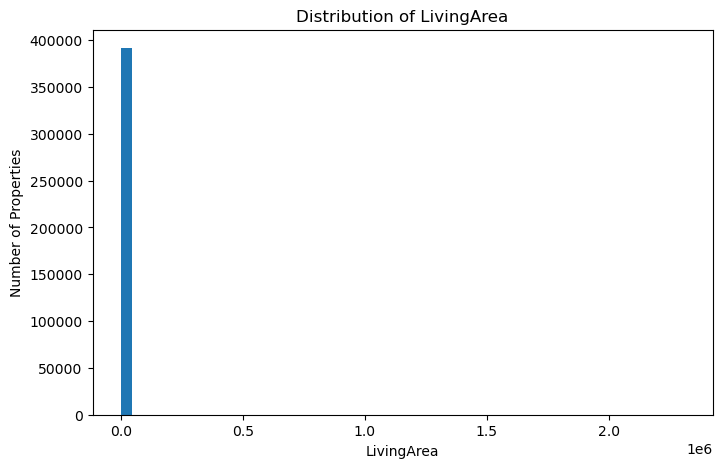

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["LivingArea"], bins=50)
plt.title("Distribution of LivingArea")
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.show()

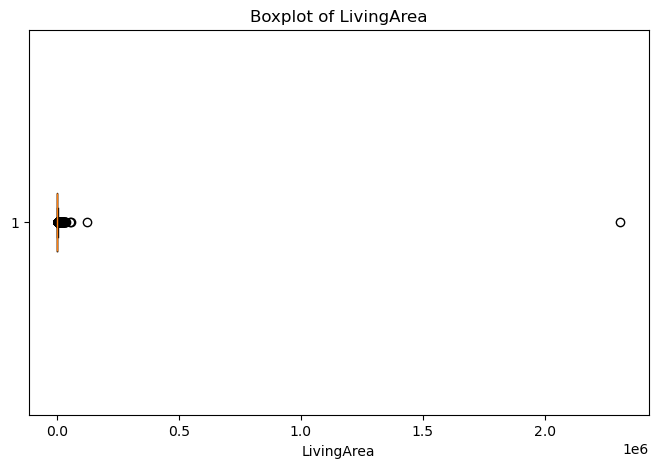

In [16]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_eda["LivingArea"], vert=False)
plt.title("Boxplot of LivingArea")
plt.xlabel("LivingArea")
plt.show()

99th percentile LivingArea: 5657.0
Rows before zoom filter: 391675
Rows after zoom filter: 387759


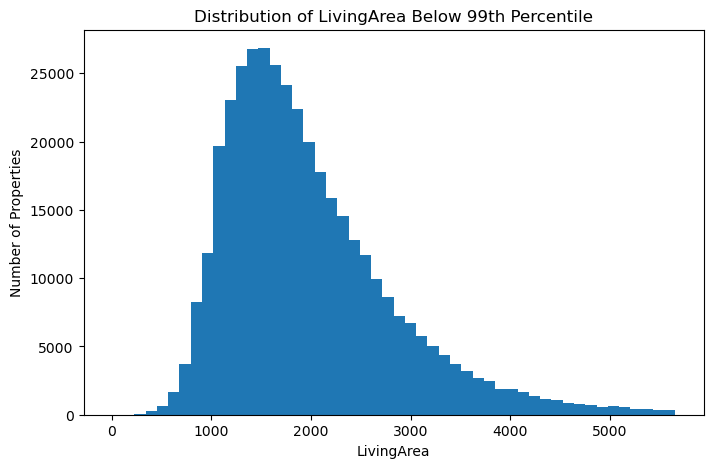

In [17]:
livingarea_99 = df_eda["LivingArea"].quantile(0.99)

df_living_zoom = df_eda[df_eda["LivingArea"] <= livingarea_99]

print("99th percentile LivingArea:", livingarea_99)
print("Rows before zoom filter:", len(df_eda))
print("Rows after zoom filter:", len(df_living_zoom))

plt.figure(figsize=(8, 5))
plt.hist(df_living_zoom["LivingArea"], bins=50)
plt.title("Distribution of LivingArea Below 99th Percentile")
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.show()

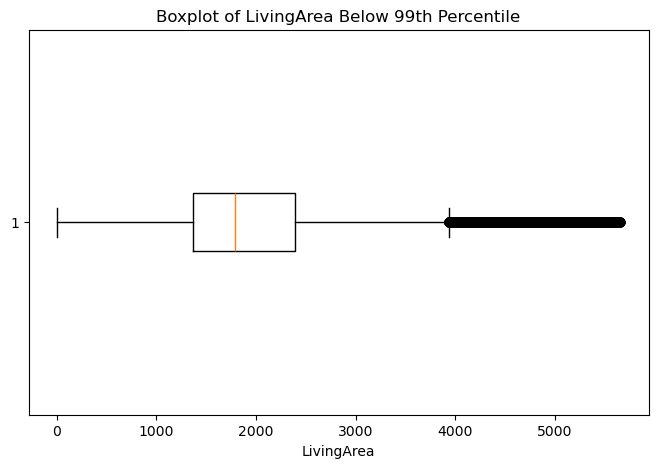

In [18]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_living_zoom["LivingArea"], vert=False)
plt.title("Boxplot of LivingArea Below 99th Percentile")
plt.xlabel("LivingArea")
plt.show()

The LivingArea distribution shows that most residential single-family homes are around 1,000 to 2,500 square feet, with the highest concentration around 1,400 to 1,800 square feet. The distribution is right-skewed because fewer homes have very large living areas. The boxplot also shows that homes above roughly 4,000 square feet appear as high-end outliers compared with the main group.

### **3. Plot for Bedrooms**

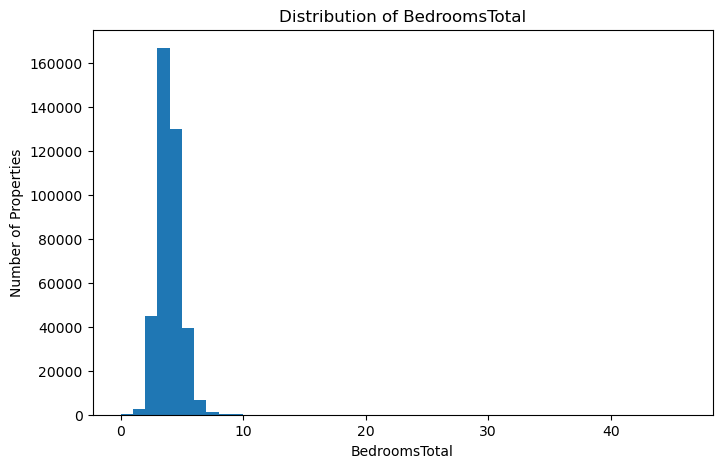

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["BedroomsTotal"], bins=range(0, int(df_eda["BedroomsTotal"].max()) + 2))
plt.title("Distribution of BedroomsTotal")
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.show()

In [20]:
df_eda["BedroomsTotal"].max()

np.float64(45.0)

In [21]:
df_eda["BedroomsTotal"].value_counts().sort_index()

BedroomsTotal
0.0        178
1.0       2561
2.0      44750
3.0     166587
4.0     129662
5.0      39382
6.0       6665
7.0       1311
8.0        365
9.0        103
10.0        51
11.0        18
12.0        16
13.0         9
14.0         3
15.0         5
16.0         2
17.0         1
19.0         1
22.0         2
31.0         1
34.0         1
45.0         1
Name: count, dtype: int64

The BedroomsTotal distribution shows that most residential single-family homes have 3 or 4 bedrooms. There are some records with very high bedroom counts, including a maximum of 45 bedrooms, but these are extremely rare. For example, only one record has 45 bedrooms, while over 166,000 homes have 3 bedrooms and about 130,000 homes have 4 bedrooms. This suggests that very high bedroom counts are outliers compared with the main group.

### **4. Plot for BathroomsTotalInteger**

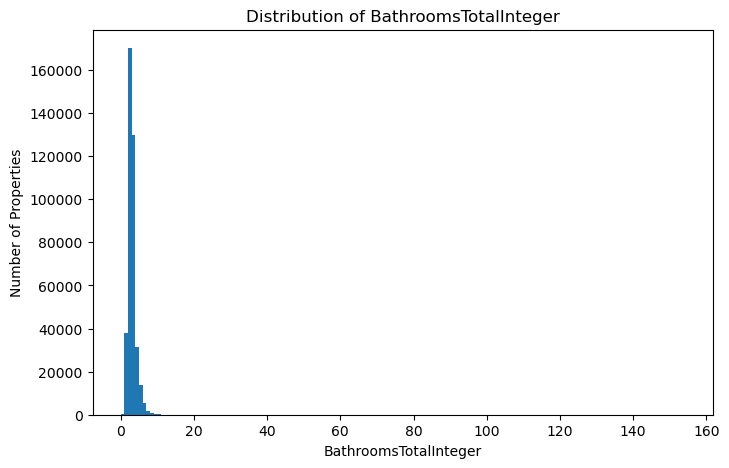

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["BathroomsTotalInteger"], bins=range(0, int(df_eda["BathroomsTotalInteger"].max()) + 2))
plt.title("Distribution of BathroomsTotalInteger")
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.show()

In [23]:
df_eda["BathroomsTotalInteger"].value_counts().sort_index()

BathroomsTotalInteger
0.0         121
1.0       37793
2.0      170205
3.0      129690
4.0       31491
5.0       13584
6.0        5350
7.0        1899
8.0         782
9.0         370
10.0        169
11.0         84
12.0         56
13.0         29
14.0         17
15.0         10
16.0          5
17.0          2
18.0          2
20.0          4
21.0          2
22.0          2
23.0          1
24.0          1
25.0          1
27.0          2
35.0          1
45.0          1
153.0         1
Name: count, dtype: int64

In [24]:
df_eda["BathroomsTotalInteger"].max()

np.float64(153.0)

99th percentile BedroomsTotal: 6.0


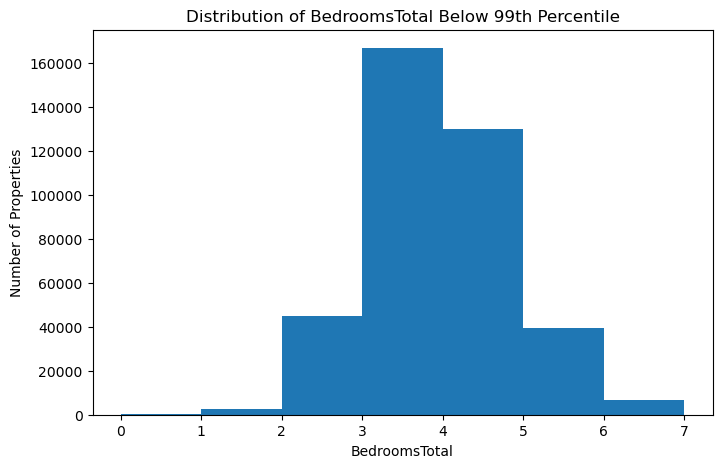

In [26]:
bedroom_99 = df_eda["BedroomsTotal"].quantile(0.99)

df_bedroom_zoom = df_eda[df_eda["BedroomsTotal"] <= bedroom_99]

print("99th percentile BedroomsTotal:", bedroom_99)

plt.figure(figsize=(8, 5))
plt.hist(
    df_bedroom_zoom["BedroomsTotal"],
    bins=range(0, int(df_bedroom_zoom["BedroomsTotal"].max()) + 2)
)
plt.title("Distribution of BedroomsTotal Below 99th Percentile")
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.show()

After limiting BedroomsTotal to values below the 99th percentile, the main distribution is easier to see. Most residential single-family homes have 3 or 4 bedrooms, with 3-bedroom homes appearing most common. Homes with 6 or more bedrooms are much less common compared with the main group.

99th percentile BathroomsTotalInteger: 6.0
Rows before zoom filter: 391675
Rows after zoom filter: 388234


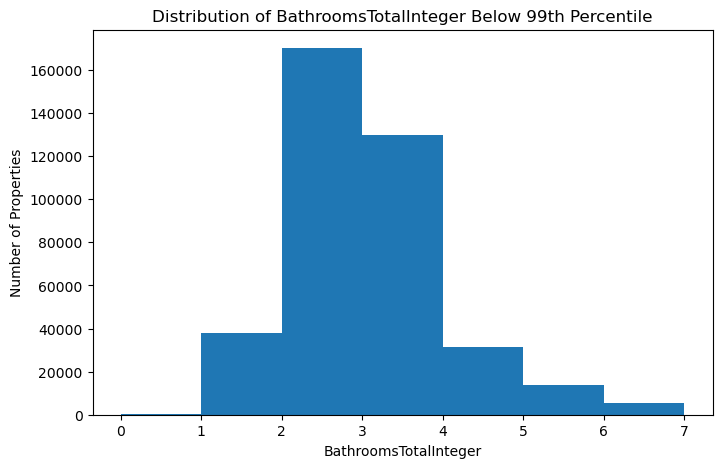

In [25]:
bathroom_99 = df_eda["BathroomsTotalInteger"].quantile(0.99)

df_bathroom_zoom = df_eda[df_eda["BathroomsTotalInteger"] <= bathroom_99]

print("99th percentile BathroomsTotalInteger:", bathroom_99)
print("Rows before zoom filter:", len(df_eda))
print("Rows after zoom filter:", len(df_bathroom_zoom))

plt.figure(figsize=(8, 5))
plt.hist(
    df_bathroom_zoom["BathroomsTotalInteger"],
    bins=range(0, int(df_bathroom_zoom["BathroomsTotalInteger"].max()) + 2)
)
plt.title("Distribution of BathroomsTotalInteger Below 99th Percentile")
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.show()

After limiting BathroomsTotalInteger to values below the 99th percentile, the main distribution becomes easier to see. Most residential single-family homes have 2 or 3 bathrooms, while homes with 5 or more bathrooms are much less common. This shows that the original bathroom plot was stretched by a few extreme outlier values.

### **5. Plot for LotSizeSquareFeet**

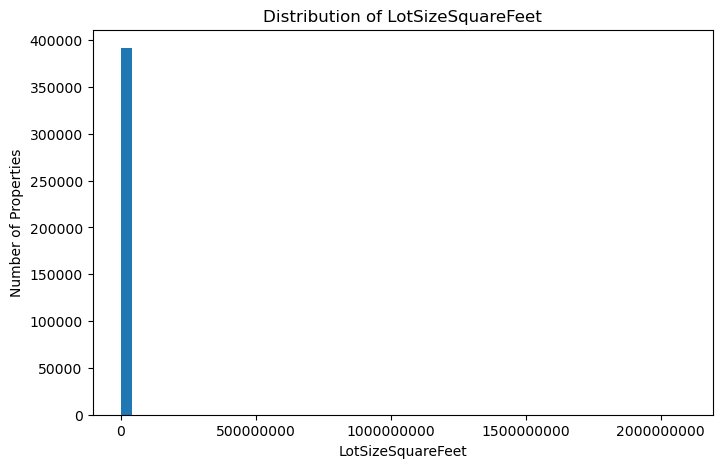

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["LotSizeSquareFeet"], bins=50)
plt.title("Distribution of LotSizeSquareFeet")
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

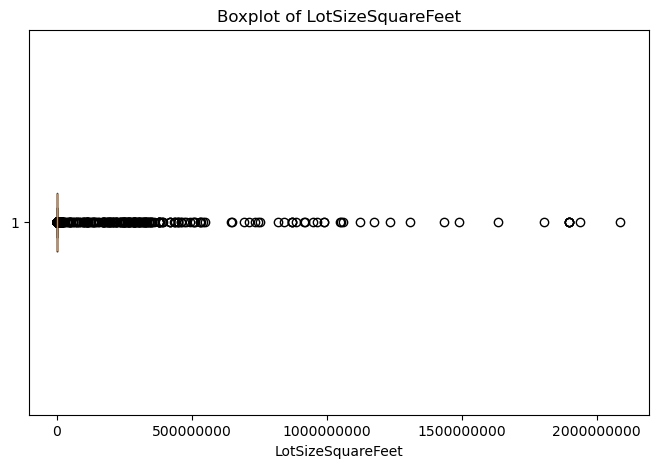

In [28]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_eda["LotSizeSquareFeet"], vert=False)
plt.title("Boxplot of LotSizeSquareFeet")
plt.xlabel("LotSizeSquareFeet")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

The original LotSizeSquareFeet histogram and boxplot are difficult to read because a few properties have extremely large lot sizes. These outliers stretch the x-axis, causing most typical residential lot sizes to be compressed near the left side of the graph.

99th percentile LotSizeSquareFeet: 257033.64000000106
Rows before zoom filter: 391675
Rows after zoom filter: 387758


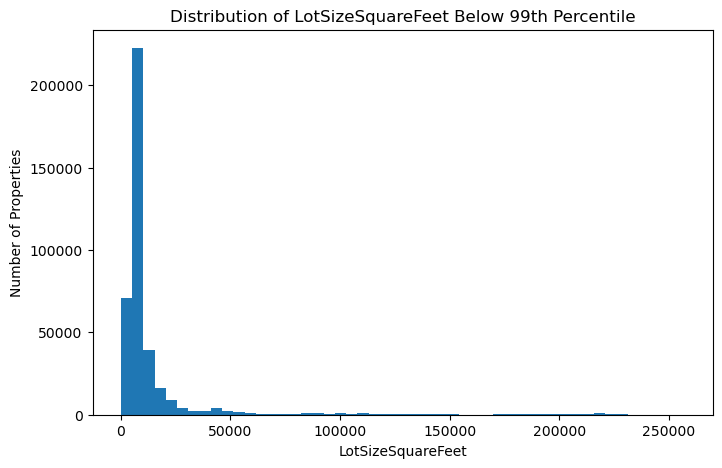

In [29]:
lotsize_99 = df_eda["LotSizeSquareFeet"].quantile(0.99)

df_lotsize_zoom = df_eda[df_eda["LotSizeSquareFeet"] <= lotsize_99]

print("99th percentile LotSizeSquareFeet:", lotsize_99)
print("Rows before zoom filter:", len(df_eda))
print("Rows after zoom filter:", len(df_lotsize_zoom))

plt.figure(figsize=(8, 5))
plt.hist(df_lotsize_zoom["LotSizeSquareFeet"], bins=50)
plt.title("Distribution of LotSizeSquareFeet Below 99th Percentile")
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

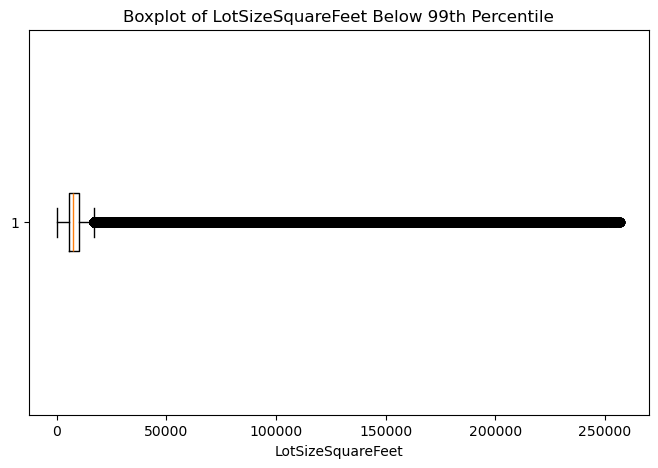

In [30]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_lotsize_zoom["LotSizeSquareFeet"], vert=False)
plt.title("Boxplot of LotSizeSquareFeet Below 99th Percentile")
plt.xlabel("LotSizeSquareFeet")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

After limiting LotSizeSquareFeet to values below the 99th percentile, the distribution is still highly right-skewed. Most residential single-family homes have relatively smaller lot sizes, while fewer homes have very large lots. The boxplot shows many high lot-size outliers, which suggests that lot size varies much more widely than bedrooms or bathrooms.

## Week 2 Summary

For Week 2, I loaded Load all available CRMLS sold-listing files data into pandas and filtered the dataset to residential single-family homes. I explored the distributions of ClosePrice, LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeSquareFeet using summary statistics, histograms, boxplots, and 99th percentile plots.

The EDA showed that ClosePrice, LivingArea, and LotSizeSquareFeet are right-skewed, meaning most homes are concentrated in a typical range while a smaller number of expensive, large, or high-lot-size homes stretch the distributions to the right. BedroomsTotal and BathroomsTotalInteger are more concentrated, with most homes having around 3–4 bedrooms and 2–3 bathrooms. Overall, this notebook helped identify the main patterns and outliers in the residential single-family home data before deeper analysis.